# Out-of-Sample Validation

Chronological train/test split (train: meetings before 2022; test: 2022 onward), evaluating out-of-sample R² and directional accuracy for each specification from the full-sample regression.

## Step 0 — Path setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import binomtest

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\hp\Desktop\rbi-sentiment-market-forecast


## Step 1 — Load data and split chronologically

In [2]:
from paths import MERGED_CSV

merged = pd.read_csv(MERGED_CSV, parse_dates=["listed_date"])

SPLIT_DATE = "2022-01-01"
train = merged[merged["listed_date"] < SPLIT_DATE].copy()
test = merged[merged["listed_date"] >= SPLIT_DATE].copy()

print(f"Train: {len(train)} meetings, {train['listed_date'].min().date()} to {train['listed_date'].max().date()}")
print(f"Test:  {len(test)} meetings, {test['listed_date'].min().date()} to {test['listed_date'].max().date()}")

Train: 32 meetings, 2016-10-04 to 2021-12-08
Test:  29 meetings, 2022-02-10 to 2026-08-05


## Step 2 — Fit on train, evaluate on test

Out-of-sample R² is benchmarked against the training-set mean (not the test set's own mean, which would leak future information). Directional accuracy tests whether the sign of the predicted move matches the sign of the actual move, with a one-sided binomial test against a 50% chance baseline.

In [3]:
def out_of_sample_check(y_col, x_cols, train_df, test_df, label):
    tr = train_df[x_cols + [y_col]].dropna()
    te = test_df[x_cols + [y_col]].dropna()

    X_tr = sm.add_constant(tr[x_cols])
    y_tr = tr[y_col]
    model = sm.OLS(y_tr, X_tr).fit()

    X_te = sm.add_constant(te[x_cols], has_constant="add")
    y_te = te[y_col]
    y_pred = model.predict(X_te)

    train_mean = y_tr.mean()
    ss_res = np.sum((y_te - y_pred) ** 2)
    ss_tot = np.sum((y_te - train_mean) ** 2)
    oos_r2 = 1 - ss_res / ss_tot

    correct = int((np.sign(y_pred) == np.sign(y_te)).sum())
    total = len(y_te)
    acc = correct / total
    binom = binomtest(correct, total, 0.5, alternative="greater")

    print(f"{'='*65}\n{label}\n{'='*65}")
    print(f"In-sample R-squared (train, n={len(tr)}):  {model.rsquared:.3f}")
    print(f"Sentiment coefficient p-value (train):     {model.pvalues[x_cols[0]]:.4f}")
    print(f"Out-of-sample R-squared (test, n={total}):    {oos_r2:.3f}")
    print(f"Directional accuracy:                      {correct}/{total} = {acc*100:.1f}%")
    print(f"  (vs. 50% chance baseline -- one-sided binomial test p={binom.pvalue:.4f})")
    print()
    return model, y_pred, y_te

model_1d, pred_1d, actual_1d = out_of_sample_check(
    "dyield_1d", ["lexicon_score_x1000", "repo_rate_change_bps"], train, test,
    "1-day G-Sec yield change"
)

1-day G-Sec yield change
In-sample R-squared (train, n=32):  0.014
Sentiment coefficient p-value (train):     0.7255
Out-of-sample R-squared (test, n=29):    0.128
Directional accuracy:                      17/29 = 58.6%
  (vs. 50% chance baseline -- one-sided binomial test p=0.2291)



In [4]:
model_3d, pred_3d, actual_3d = out_of_sample_check(
    "dyield_3d", ["lexicon_score_x1000", "repo_rate_change_bps"], train, test,
    "3-day G-Sec yield change"
)

3-day G-Sec yield change
In-sample R-squared (train, n=32):  0.005
Sentiment coefficient p-value (train):     0.7048
Out-of-sample R-squared (test, n=29):    -0.043
Directional accuracy:                      20/29 = 69.0%
  (vs. 50% chance baseline -- one-sided binomial test p=0.0307)



In [5]:
model_fx, pred_fx, actual_fx = out_of_sample_check(
    "dusdinr_1d_pct", ["lexicon_score_x1000", "repo_rate_change_bps"], train, test,
    "1-day USD/INR %% change"
)

1-day USD/INR %% change
In-sample R-squared (train, n=32):  0.014
Sentiment coefficient p-value (train):     0.7193
Out-of-sample R-squared (test, n=29):    0.010
Directional accuracy:                      18/29 = 62.1%
  (vs. 50% chance baseline -- one-sided binomial test p=0.1325)



## Step 3 — Predicted vs. actual (test set)

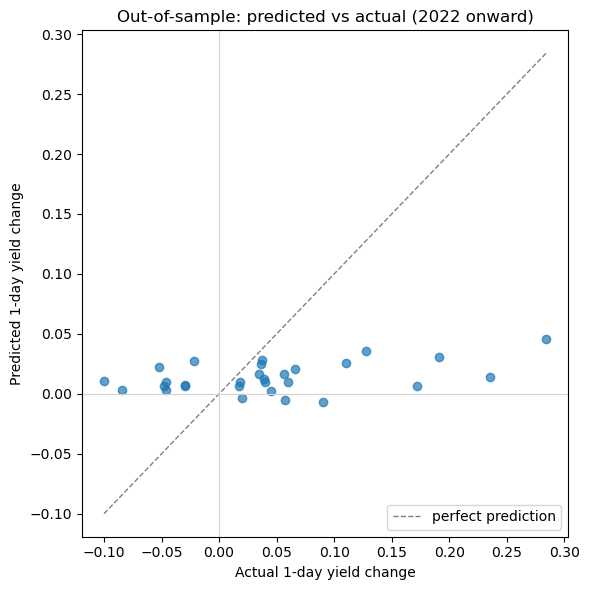

In [6]:
import matplotlib.pyplot as plt
from paths import FIGURES_DIR

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(actual_1d, pred_1d, alpha=0.7)
lims = [min(actual_1d.min(), pred_1d.min()), max(actual_1d.max(), pred_1d.max())]
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, label="perfect prediction")
ax.axhline(0, color="lightgray", linewidth=0.8)
ax.axvline(0, color="lightgray", linewidth=0.8)
ax.set_xlabel("Actual 1-day yield change")
ax.set_ylabel("Predicted 1-day yield change")
ax.set_title("Out-of-sample: predicted vs actual (2022 onward)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "out_of_sample_predicted_vs_actual.png", dpi=150)
plt.show()

---

**Result.** The 3-day yield window shows statistically significant out-of-sample directional accuracy (69.0%, p=0.031) despite a negative out-of-sample R² — R² penalizes magnitude error, while directional accuracy evaluates sign only; a model can be a weak magnitude forecaster while remaining a reliable direction indicator. The 1-day yield and 1-day FX specifications do not reach significance.